<a href="https://colab.research.google.com/github/MathusiganSenthan/machine-learning-Group-Pro/blob/Logistic-regression-it22569318/IT22569318.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# breast_cancer_logistic_regression.py

# -------------------------------
# 1. Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [6]:
import joblib

# -------------------------------
# 2. Load Dataset
# -------------------------------
# If using Colab: upload your data.csv first
df = pd.read_csv('/content/drive/MyDrive/Python /IT4010-ML/Assignment/data.csv')

# Preview dataset
print("Dataset Preview:")
print(df.head())
print("\nColumns:", df.columns)
print("\nInfo:")
print(df.info())

Dataset Preview:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_

In [7]:
# -------------------------------
# 3. Preprocessing
# -------------------------------
# Drop unnecessary columns
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Encode target: M = Malignant (1), B = Benign (0)
df['target'] = df['diagnosis'].map({'M': 1, 'B': 0})
df = df.drop('diagnosis', axis=1)

# Check target distribution
print("\nTarget Distribution:")
print(df['target'].value_counts())


Target Distribution:
target
0    357
1    212
Name: count, dtype: int64


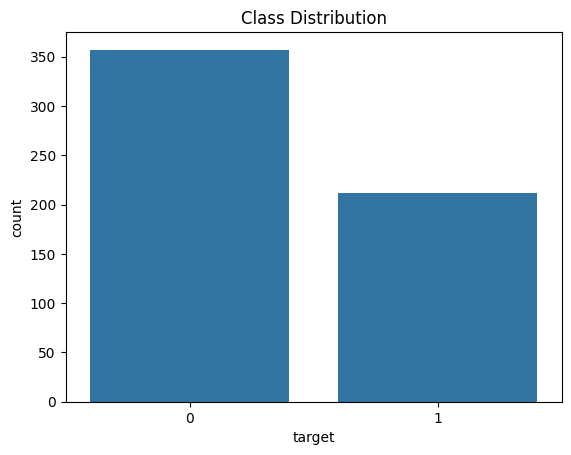

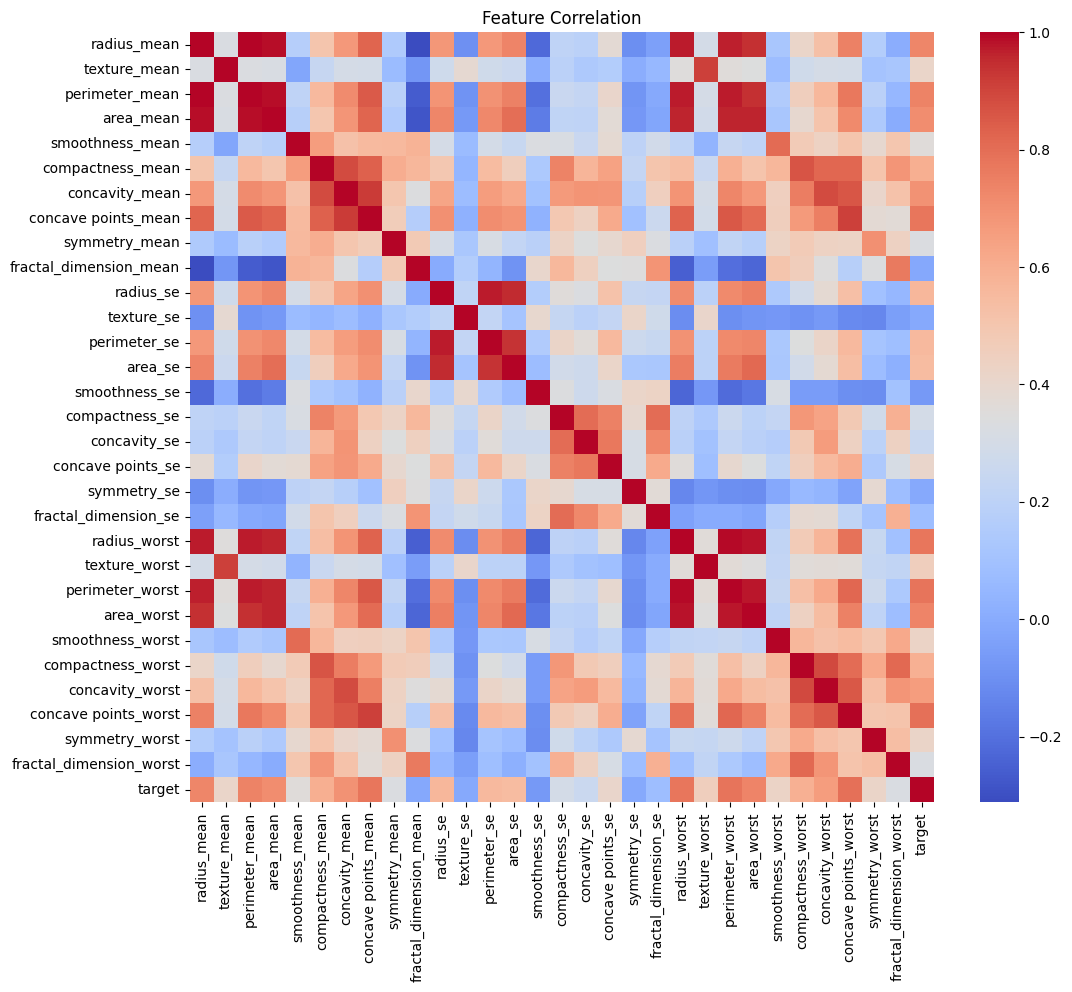

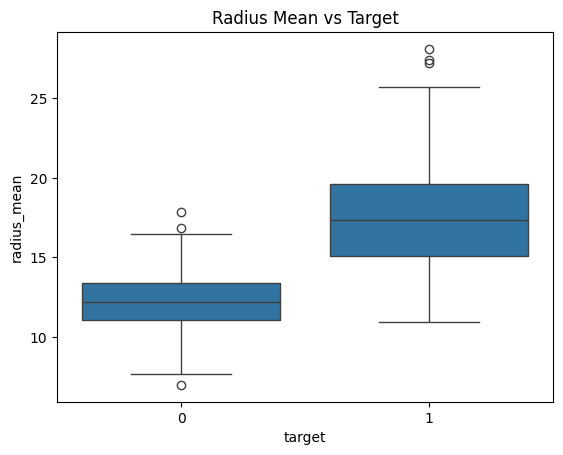

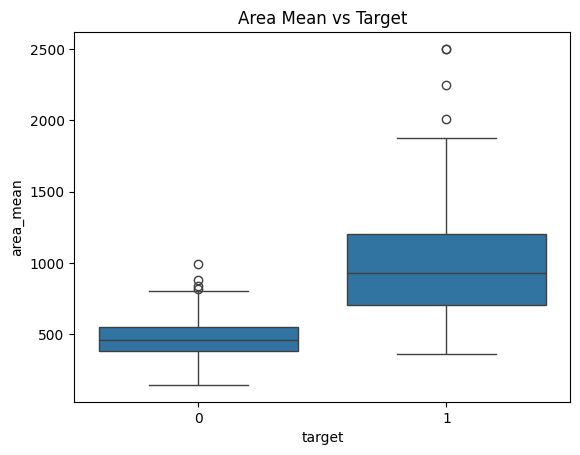

In [8]:
# -------------------------------
# 4. Exploratory Data Analysis
# -------------------------------
# Class distribution
sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Boxplots for important features
sns.boxplot(x='target', y='radius_mean', data=df)
plt.title("Radius Mean vs Target")
plt.show()

sns.boxplot(x='target', y='area_mean', data=df)
plt.title("Area Mean vs Target")
plt.show()


In [9]:
# -------------------------------
# 5. Feature Engineering
# -------------------------------
# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# Optional: remove highly correlated features to avoid multicollinearity
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X = X.drop(columns=to_drop)
print("\nDropped highly correlated columns:", to_drop)


Dropped highly correlated columns: ['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']


In [10]:
# -------------------------------
# 6. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# -------------------------------
# 7. Build Pipeline
# -------------------------------
model = LogisticRegression(
    solver='saga',
    max_iter=2000,
    C=0.05,
    class_weight='balanced'
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', model)
])

In [12]:
# -------------------------------
# 8. Train Model
# -------------------------------
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(C=0.05, class_weight='balanced',
                                    max_iter=2000, solver='saga'))])

In [13]:
# -------------------------------
# 9. Predictions
# -------------------------------
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]


Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



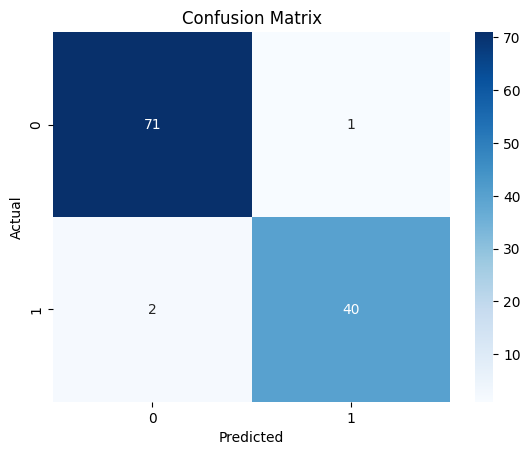

ROC-AUC: 0.9970238095238095


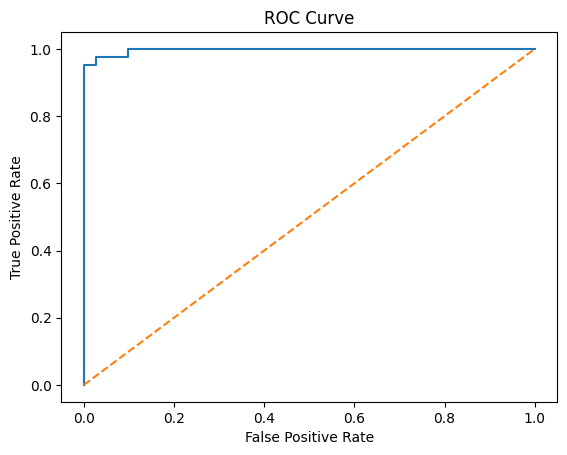

In [14]:
# -------------------------------
# 10. Evaluation
# -------------------------------
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC-AUC Curve
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [15]:
# -------------------------------
# 11. Cross Validation
# -------------------------------
cv_scores = cross_val_score(pipeline, X, y, cv=5)
print("5-Fold CV Accuracy:", cv_scores.mean())

5-Fold CV Accuracy: 0.9595870206489675


In [16]:
# -------------------------------
# 12. Feature Importance
# -------------------------------
coefficients = pipeline.named_steps['classifier'].coef_[0]
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 10 Feature Importance:")
print(feature_importance.head(10))


Top 10 Feature Importance:
              Feature  Coefficient
0         radius_mean     0.955566
7           radius_se     0.674262
1        texture_mean     0.582474
4      concavity_mean     0.519108
17    concavity_worst     0.443508
18     symmetry_worst     0.425940
15   smoothness_worst     0.352340
12  concave points_se     0.281226
16  compactness_worst     0.268527
3    compactness_mean     0.240934
